In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
import folium
from folium.plugins import HeatMap
import glob
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from sklearn.metrics import pairwise_distances
from scipy.linalg import sqrtm
from scipy.special import digamma, loggamma
from math import pi
import contextily as ctx

In [2]:
NewestAdvan = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/us_weekly_plus_may_2025_visit_counts.csv')

In [3]:
NewestAdvan['naics2'] = NewestAdvan['naics_code'].astype(str).str[:2]
NewestAdvan['naics2'].unique()

array(['71', '72', '42', '44', '23', '81', '45', '48', '53', '54', '52',
       '32', '49', '51', '33', '31', '22', '61', '56', '11', '92', '55',
       '21'], dtype=object)

In [4]:
NewestAdvan_VA = NewestAdvan.copy()
NewestAdvan_VA['poi_cbg'] = NewestAdvan_VA['poi_cbg'].astype(str)
NewestAdvan_VA.loc[NewestAdvan_VA['poi_cbg'].str.len() == 11, 'poi_cbg'] = '0' + NewestAdvan_VA['poi_cbg']
NewestAdvan_VA = NewestAdvan_VA[NewestAdvan_VA['poi_cbg'].str.len() == 12]
NewestAdvan_VA = NewestAdvan_VA[NewestAdvan_VA['poi_cbg'].str[:2] == '51']
NewestAdvan_VA['region'] = 'va'
NewestAdvan_VA['county'] = NewestAdvan_VA['poi_cbg'].str[2:5]
NewestAdvan_VA = NewestAdvan_VA[NewestAdvan_VA['SUM_VISIT_COUNTS'] > 0]
NewestAdvan_VA = NewestAdvan_VA[['id_store', 'region', 'longitude', 'latitude', 'naics2', 'poi_cbg', 'county', 'SUM_VISIT_COUNTS']]
NewestAdvan_VA.to_csv('NewestAdvan_VA.csv', index=False)

In [5]:
print(NewestAdvan_VA.head())

Empty DataFrame
Columns: [id_store, region, longitude, latitude, naics2, poi_cbg, county, SUM_VISIT_COUNTS]
Index: []


In [7]:
NewestAdvan_VA = NewestAdvan.copy()
print("start:", len(NewestAdvan_VA))

NewestAdvan_VA['poi_cbg'] = NewestAdvan_VA['poi_cbg'].astype(str).str.replace(r'\.0$', '', regex=True)
print("after strip .0:", len(NewestAdvan_VA), NewestAdvan_VA['poi_cbg'].head().tolist())
print("lengths:", NewestAdvan_VA['poi_cbg'].str.len().value_counts())

NewestAdvan_VA.loc[NewestAdvan_VA['poi_cbg'].str.len() == 11, 'poi_cbg'] = '0' + NewestAdvan_VA['poi_cbg']
print("lengths after padding:", NewestAdvan_VA['poi_cbg'].str.len().value_counts())

NewestAdvan_VA = NewestAdvan_VA[NewestAdvan_VA['poi_cbg'].str.len() == 12]
print("after len==12 filter:", len(NewestAdvan_VA))

NewestAdvan_VA = NewestAdvan_VA[NewestAdvan_VA['poi_cbg'].str[:2] == '51']
print("after state==51 filter:", len(NewestAdvan_VA))

NewestAdvan_VA['region'] = 'va'
NewestAdvan_VA['county'] = NewestAdvan_VA['poi_cbg'].str[2:5]

NewestAdvan_VA = NewestAdvan_VA[NewestAdvan_VA['SUM_VISIT_COUNTS'] > 0]
print("after visit_counts filter:", len(NewestAdvan_VA))

NewestAdvan_VA = NewestAdvan_VA[['id_store', 'region', 'longitude', 'latitude', 'naics2', 'poi_cbg', 'county', 'SUM_VISIT_COUNTS']]
NewestAdvan_VA.to_csv('NewestAdvan_VA.csv', index=False)

start: 5408963
after strip .0: 5408963 ['131210103123', '530530703153', '260270022012', '180973812051', '515200201002']
lengths: poi_cbg
12    4272292
11     956820
8      176050
3        3425
14        376
Name: count, dtype: int64
lengths after padding: poi_cbg
12    5229112
8      176050
3        3425
14        376
Name: count, dtype: int64
after len==12 filter: 5229112
after state==51 filter: 120808
after visit_counts filter: 120808


In [8]:
NewestAdvan_VA = NewestAdvan.copy()
NewestAdvan_VA['poi_cbg'] = NewestAdvan_VA['poi_cbg'].astype(str).str.replace(r'\.0$', '', regex=True)
NewestAdvan_VA.loc[NewestAdvan_VA['poi_cbg'].str.len() == 11, 'poi_cbg'] = '0' + NewestAdvan_VA['poi_cbg']
NewestAdvan_VA = NewestAdvan_VA[NewestAdvan_VA['poi_cbg'].str.len() == 12]
NewestAdvan_VA = NewestAdvan_VA[NewestAdvan_VA['poi_cbg'].str[:2] == '51']
NewestAdvan_VA['region'] = 'va'
NewestAdvan_VA['county'] = NewestAdvan_VA['poi_cbg'].str[2:5]
NewestAdvan_VA = NewestAdvan_VA[NewestAdvan_VA['SUM_VISIT_COUNTS'] > 0]
NewestAdvan_VA = NewestAdvan_VA[['id_store', 'region', 'longitude', 'latitude', 'naics2', 'poi_cbg', 'county', 'SUM_VISIT_COUNTS']]
NewestAdvan_VA.to_csv('NewestAdvan_VA.csv', index=False)

In [3]:
FirstAdvan = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/Advan.csv')

In [3]:
print(NewestAdvan.columns)

Index(['id_store', 'REGION', 'longitude', 'latitude', 'naics_code', 'poi_cbg',
       'VISITS_BY_DAY_2025_05_05', 'VISITS_BY_DAY_2025_05_12',
       'VISITS_BY_DAY_2025_05_19', 'VISITS_BY_DAY_2025_05_26',
       'VISIT_COUNTS_2025_05_05', 'VISIT_COUNTS_2025_05_12',
       'VISIT_COUNTS_2025_05_19', 'VISIT_COUNTS_2025_05_26',
       'SUM_VISIT_COUNTS', 'MEDIAN_VISITS_BY_DAY', 'AVG_VISITS_BY_DAY'],
      dtype='object')


In [5]:
NewestAdvan['naics2'] = NewestAdvan['naics_code'].astype(str).str[:2]
NewestAdvan['poi_cbg'] = NewestAdvan['poi_cbg'].astype(str).str.zfill(12)
NewestAdvan['state'] = NewestAdvan['poi_cbg'].str[:2]
NewestAdvan['county'] = NewestAdvan['poi_cbg'].str[2:5]
NewestAdvan['state_county'] = NewestAdvan['poi_cbg'].str[:5]

In [6]:
NewestAdvan_VA = NewestAdvan[NewestAdvan['state'] == '51'].copy()

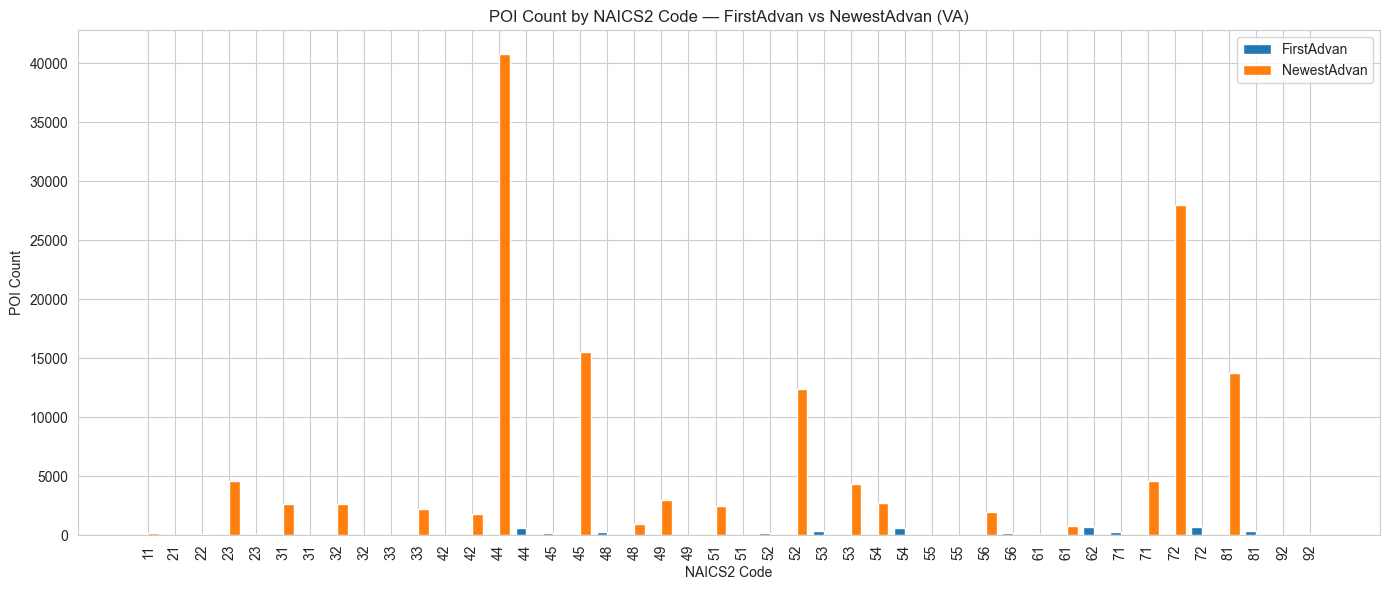

In [9]:
newest_counts = NewestAdvan_VA['naics2'].value_counts()
first_counts = FirstAdvan['naics2'].value_counts()

naics2_compare = pd.concat(
    [first_counts.rename('FirstAdvan'), newest_counts.rename('NewestAdvan')],
    axis=1
).fillna(0).astype(int)

naics2_compare.index = naics2_compare.index.astype(str)  # <-- fix
naics2_compare = naics2_compare.sort_index()

x = np.arange(len(naics2_compare))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, naics2_compare['FirstAdvan'], width, label='FirstAdvan')
ax.bar(x + width/2, naics2_compare['NewestAdvan'], width, label='NewestAdvan')

ax.set_xlabel('NAICS2 Code')
ax.set_ylabel('POI Count')
ax.set_title('POI Count by NAICS2 Code — FirstAdvan vs NewestAdvan (VA)')
ax.set_xticks(x)
ax.set_xticklabels(naics2_compare.index, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

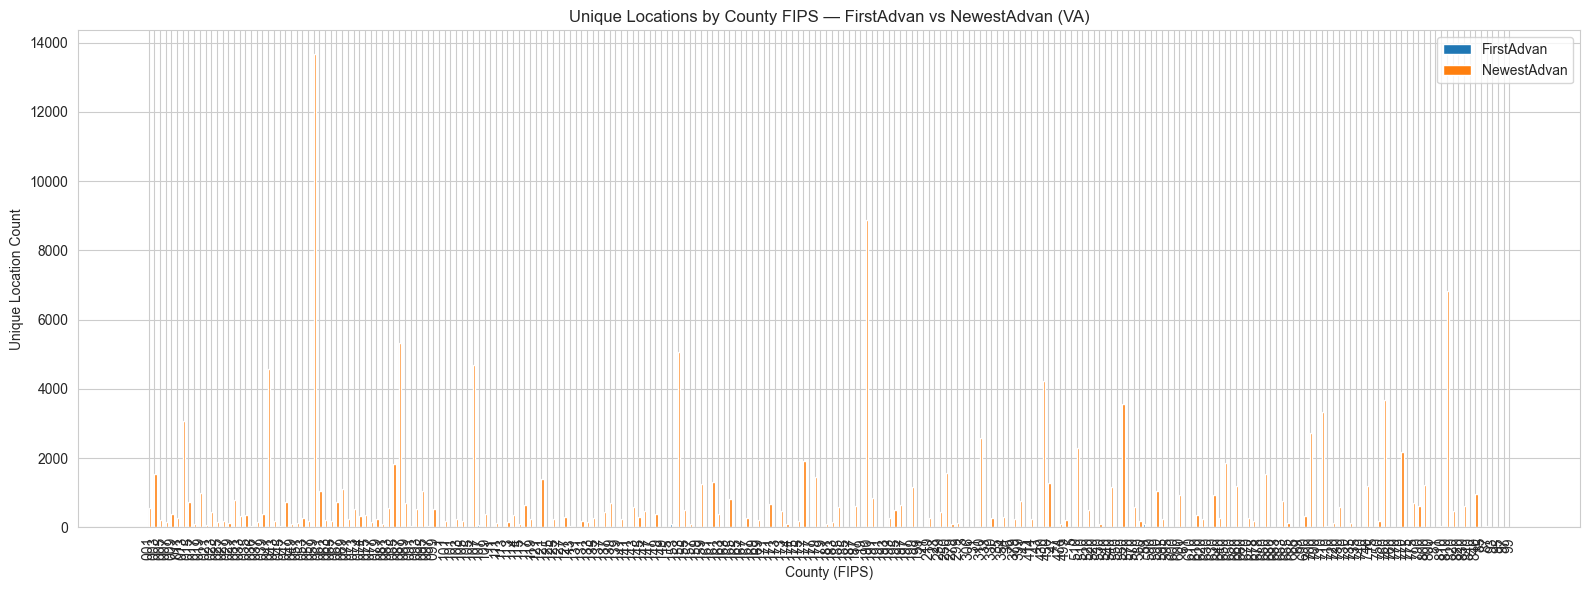

In [10]:
newest_county_unique = NewestAdvan_VA.groupby('county')['id_store'].nunique()
first_county_unique = FirstAdvan.groupby('county')['store_id'].nunique()

county_unique_compare = pd.concat(
    [first_county_unique.rename('FirstAdvan'), newest_county_unique.rename('NewestAdvan')],
    axis=1
).fillna(0).astype(int)

county_unique_compare.index = county_unique_compare.index.astype(str)
county_unique_compare = county_unique_compare.sort_index()

x = np.arange(len(county_unique_compare))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width/2, county_unique_compare['FirstAdvan'], width, label='FirstAdvan')
ax.bar(x + width/2, county_unique_compare['NewestAdvan'], width, label='NewestAdvan')

ax.set_xlabel('County (FIPS)')
ax.set_ylabel('Unique Location Count')
ax.set_title('Unique Locations by County FIPS — FirstAdvan vs NewestAdvan (VA)')
ax.set_xticks(x)
ax.set_xticklabels(county_unique_compare.index, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

In [13]:
lengths = NewestAdvan['poi_cbg'].astype(str).str.len()
print(NewestAdvan.loc[lengths == 14, 'poi_cbg'].head(10).tolist())
print(NewestAdvan.loc[lengths == 13, 'poi_cbg'].head(10).tolist())
print(NewestAdvan.loc[lengths == 16, 'poi_cbg'].head(10).tolist())

['131210103123.0', '530530703153.0', '260270022012.0', '180973812051.0', '515200201002.0', '160010023131.0', '190610012012.0', '480050003012.0', '420512607002.0', '460119588033.0']
['60730091081.0', '60590626105.0', '60990009131.0', '60650432282.0', '10890013021.0', '40130610201.0', '11150401042.0', '50350308031.0', '60290014021.0', '21980001001.0']
['25447714299137.0', '20334400545422.0', '82897939932307.0', '38422656831068.0', '11833352863620.0', '72499998610876.0', '32870083084026.0', '20142629858102.0', '18258337724721.0', '12397277779900.0']


In [14]:
NewestAdvan['poi_cbg_clean'] = NewestAdvan['poi_cbg'].astype(str).str.replace(r'\.0$', '', regex=True)
clean_lengths = NewestAdvan['poi_cbg_clean'].str.len()

print(clean_lengths.value_counts())

# Keep only plausible CBGs: 11 digits (leading zero stripped) or 12 digits (already correct)
valid_mask = clean_lengths.isin([11, 12])
print(f"Valid CBG rows: {valid_mask.sum()}")
print(f"Invalid/garbage rows: {(~valid_mask).sum()}")

# Inspect what's getting dropped before committing to dropping it
print(NewestAdvan.loc[~valid_mask, 'poi_cbg'].head(10).tolist())

poi_cbg_clean
12    4275717
11     956820
10     176050
14        376
Name: count, dtype: int64
Valid CBG rows: 5232537
Invalid/garbage rows: 176426
['0059153530.0', '0024430342.0', '0035204615.0', '0024660224.0', '0059153689.0', '0047110749.0', '0035204826.0', '0047060489.0', '0035260103.0', '0035180394.0']


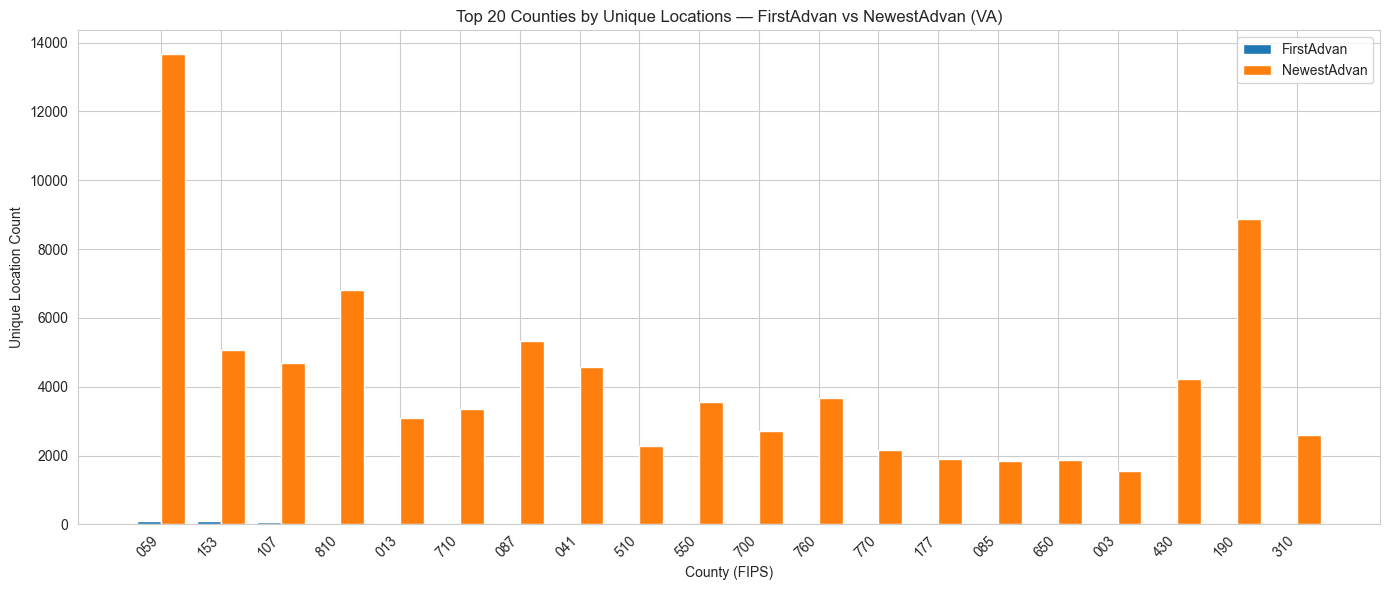

In [19]:
newest_county_unique = NewestAdvan_VA.groupby('county')['id_store'].nunique()
first_county_unique = FirstAdvan.groupby('county')['store_id'].nunique()

county_unique_compare = pd.concat(
    [first_county_unique.rename('FirstAdvan'), newest_county_unique.rename('NewestAdvan')],
    axis=1
).fillna(0).astype(int)

# Get top 20 by combined total
county_unique_compare['total'] = county_unique_compare['FirstAdvan'] + county_unique_compare['NewestAdvan']
top20 = county_unique_compare.sort_values('total', ascending=False).head(20).drop(columns='total')
top20 = top20.sort_values('FirstAdvan', ascending=False)  # descending, biggest county first left-to-right

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(top20))
width = 0.4

ax.bar(x - width/2, top20['FirstAdvan'], width, label='FirstAdvan')
ax.bar(x + width/2, top20['NewestAdvan'], width, label='NewestAdvan')

ax.set_xticks(x)
ax.set_xticklabels(top20.index, rotation=45, ha='right')
ax.set_xlabel('County (FIPS)')
ax.set_ylabel('Unique Location Count')
ax.set_title('Top 20 Counties by Unique Locations — FirstAdvan vs NewestAdvan (VA)')
ax.legend()

plt.tight_layout()
plt.show()

Unique Advan locations in Charlottesville: 1556


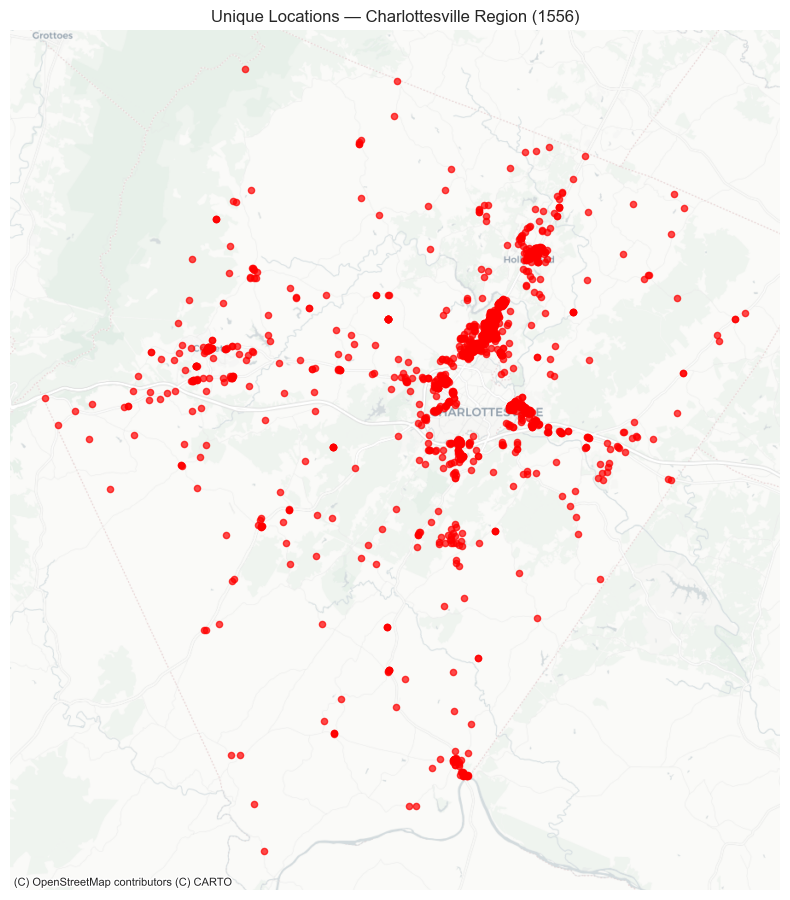

In [20]:
cville_ids = ['51003']

cville = NewestAdvan_VA[
    NewestAdvan_VA['state_county'].isin(cville_ids)
].drop_duplicates(subset='id_store')[['id_store', 'latitude', 'longitude']]

print(f"Unique Advan locations in Charlottesville: {len(cville)}")

gdf = gpd.GeoDataFrame(cville, geometry=gpd.points_from_xy(cville['longitude'], cville['latitude']),
                        crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 25))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Charlottesville Region ({len(cville)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Advan locations in DC Metro: 23654


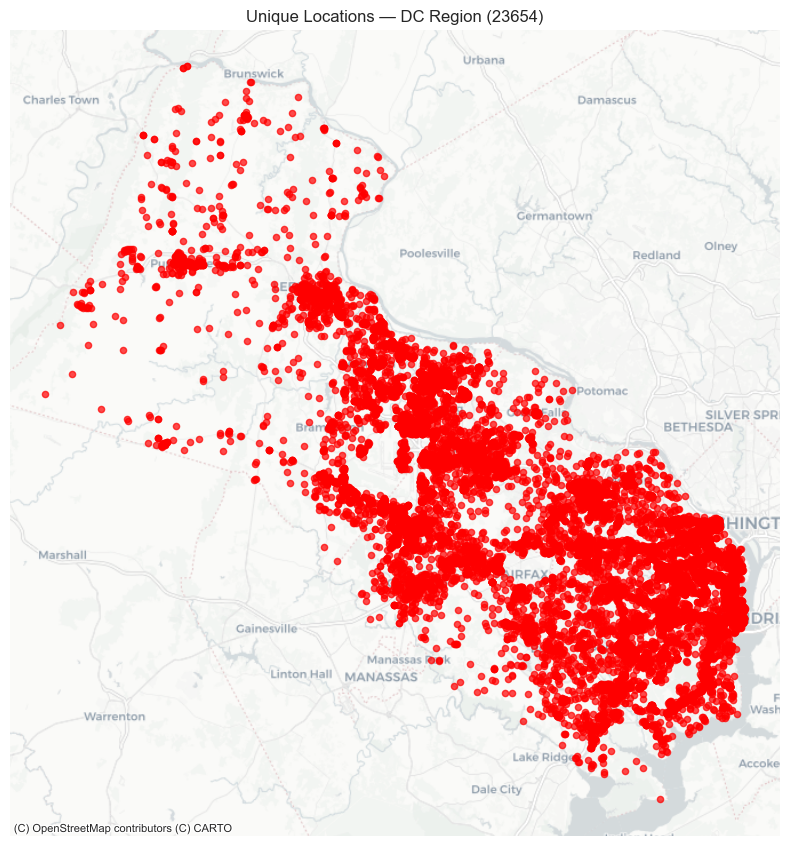

In [13]:
dc_ids = ['51059', '51013', '51510', '51107']

dc = NewestAdvan[
    NewestAdvan['state_county'].isin(dc_ids)
].drop_duplicates(subset='id_store')[['id_store', 'latitude', 'longitude']]

dc = dc[
    dc['latitude'].between(36, 40) &
    dc['longitude'].between(-79, -76)
]

print(f"Unique Advan locations in DC Metro: {len(dc)}")

gdf = gpd.GeoDataFrame(dc, geometry=gpd.points_from_xy(dc['longitude'], dc['latitude']),
                        crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 25))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — DC Region ({len(dc)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Advan locations in Richmond Region: 15400


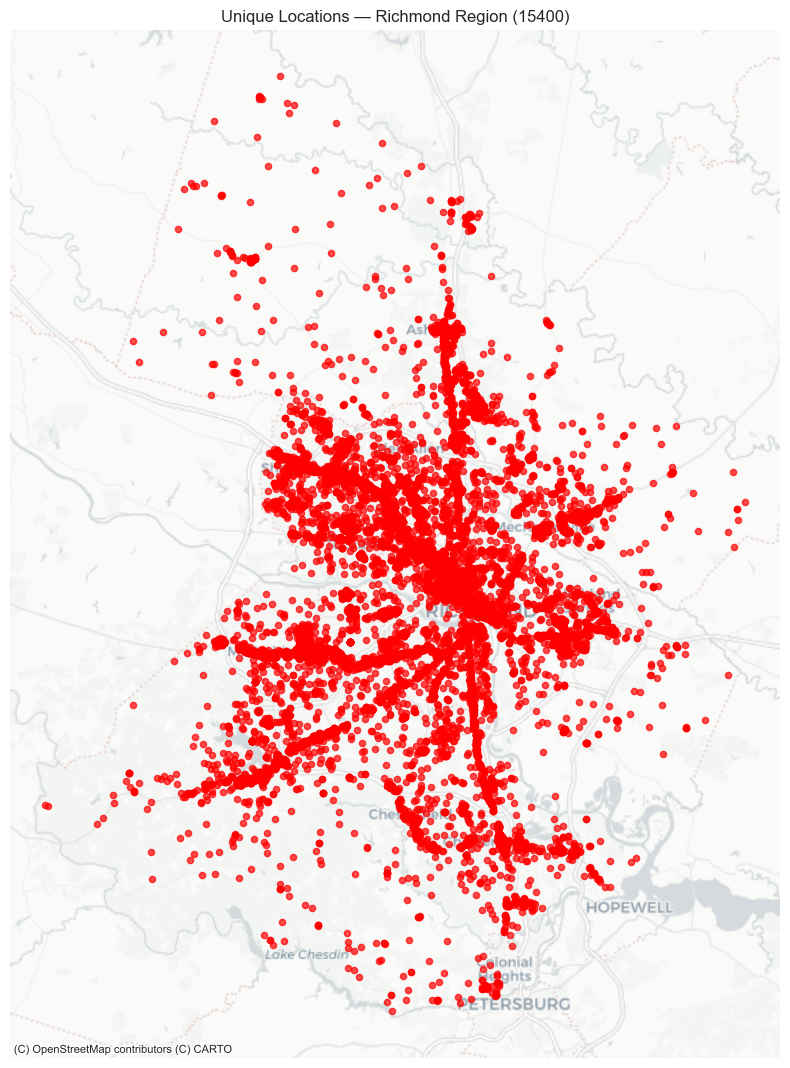

In [14]:
richmond_ids = ['51760', '51087', '51041', '51085']

richmond = NewestAdvan[
    NewestAdvan['state_county'].isin(richmond_ids)
].drop_duplicates(subset='id_store')[['id_store', 'latitude', 'longitude']]

richmond = richmond[
    richmond['latitude'].between(36, 40) &
    richmond['longitude'].between(-79, -76)
]

print(f"Unique Advan locations in Richmond Region: {len(richmond)}")

gdf = gpd.GeoDataFrame(richmond, geometry=gpd.points_from_xy(richmond['longitude'], richmond['latitude']),
                        crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 25))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Richmond Region ({len(richmond)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Advan locations in Virginia Beach Region: 18530


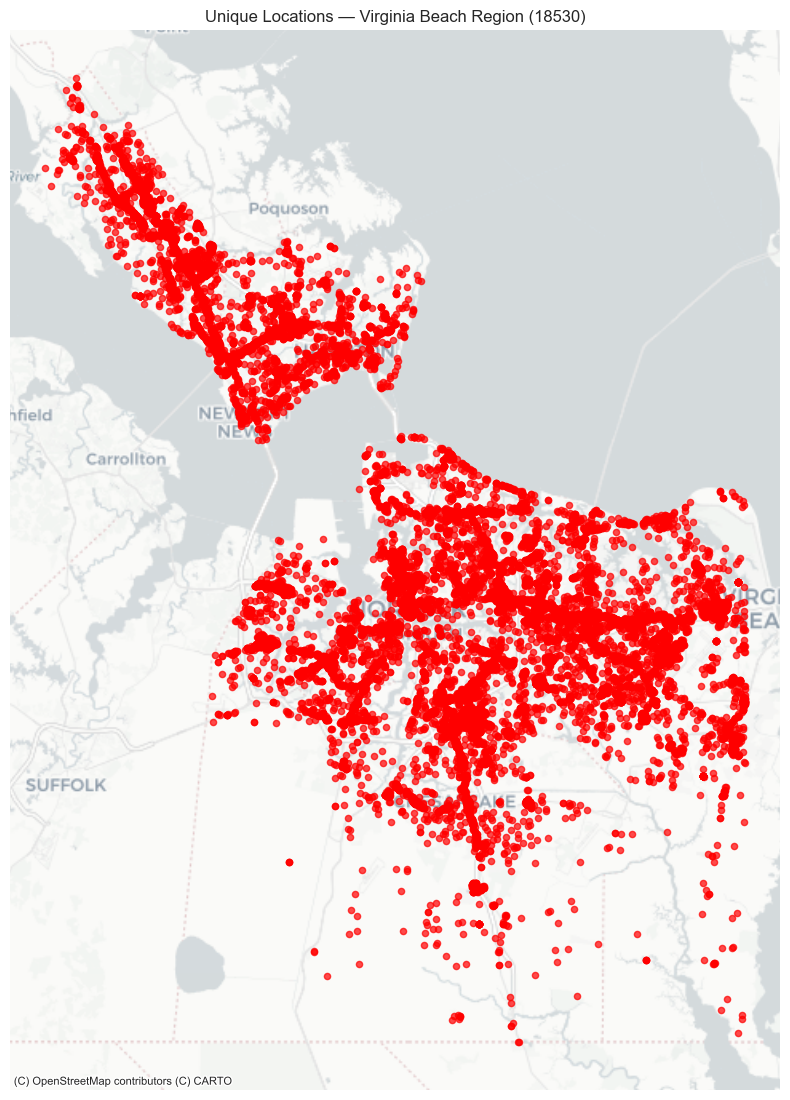

In [15]:
vb_ids = ['51810', '51710', '51550', '51740', '51650', '51700']
vb = NewestAdvan[
    NewestAdvan['state_county'].isin(vb_ids)
].drop_duplicates(subset='id_store')[['id_store', 'latitude', 'longitude']]

vb = vb[
    vb['latitude'].between(36, 40) &
    vb['longitude'].between(-79, -76)
]

print(f"Unique Advan locations in Virginia Beach Region: {len(vb)}")

gdf = gpd.GeoDataFrame(vb, geometry=gpd.points_from_xy(vb['longitude'], vb['latitude']),
                        crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 25))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Virginia Beach Region ({len(vb)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Advan locations in Roanoke Region: 3491


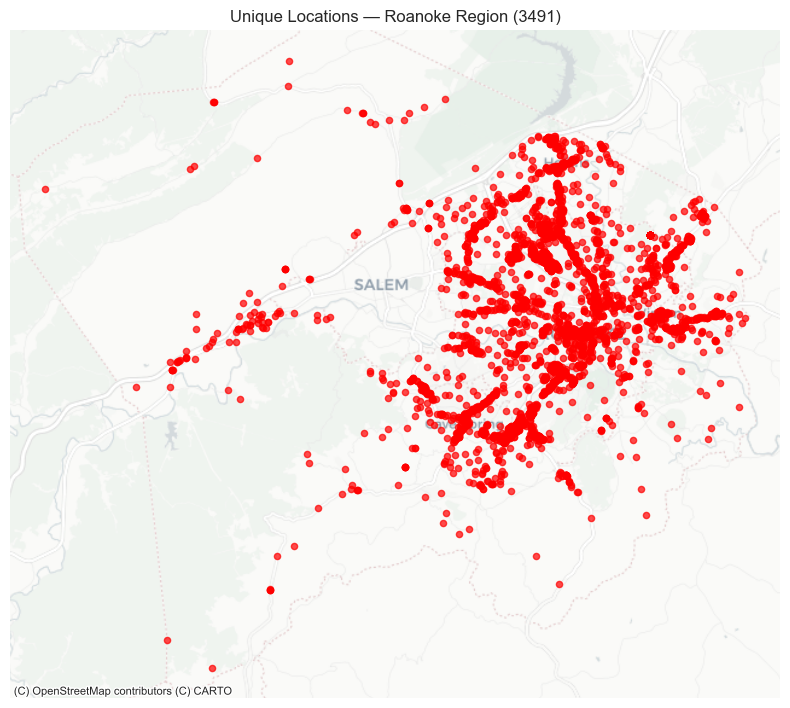

In [21]:
roanoke_ids = ['51770', '51161']

roanoke = NewestAdvan[
    NewestAdvan['state_county'].isin(roanoke_ids)
].drop_duplicates(subset='id_store')[['id_store', 'latitude', 'longitude']]

roanoke = roanoke[
    roanoke['latitude'].between(36, 40) &
    roanoke['longitude'].between(-84, -75)
]

print(f"Unique Advan locations in Roanoke Region: {len(roanoke)}")

gdf = gpd.GeoDataFrame(roanoke, geometry=gpd.points_from_xy(roanoke['longitude'], roanoke['latitude']),
                        crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 25))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Roanoke Region ({len(roanoke)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [20]:
roanoke_raw = NewestAdvan[NewestAdvan['state_county'].isin(['51770', '51161'])]
print(len(roanoke_raw))
print(roanoke_raw[['latitude', 'longitude']].describe())
print(roanoke_raw[['latitude', 'longitude']].isna().sum())

3491
          latitude    longitude
count  3491.000000  3491.000000
mean     37.280212   -79.961520
std       0.037050     0.048941
min      37.119529   -80.247040
25%      37.254825   -79.983288
50%      37.278962   -79.958619
75%      37.307480   -79.936875
max      37.394330   -79.848938
latitude     0
longitude    0
dtype: int64
